# Single-cell perturbation data

In this session, we will discuss analysing single-cell perturbation data by analysing a single-cell CRISPR screen dataset, collected from the K562 lymphoblast cell line and published by [Norman et al. in 2019](https://www.science.org/doi/10.1126/science.aax4438#supplementary-materials). The study presents a library of guide RNAs designed for use with CRISPRa system - a system which enacts up-regulation of the targeted genes - in contrast to standard CRISPR-Cas9 - a system to selectively mutate targeted genes. That said, analysis of this data will entail determining which programs are induced or repressed in response to over-expression of the perturbed gene.

This lab focuses on taking the data from its raw format through normalization and transformation specifically designed for Perturb-seq datasets to ultimately identify which genes each perturbation induces or represses. Furthermore, this experiment was designed to assess the combinatorial impact of two simultaneous perturbations. For example, if genes A and B are in different pathways which converge on the same targets, their joint over-expression may combine synergistically to drive target expression into overdrive; if they are instead on the same pathway, only the activation of the "more downstream" of the two might be important to drive the effect. To this end, we will develop a (simple) statistical model to delineate combinatorial impactss such as synerigistic and non-linear on gene expression.

Let's started!

## Setup instructions

You can either use the `DATA_DIR` variable to import the data from *data/lab_2/processed/*, or copy the data relevant for this lab into your repositories data directory with

```bash
cp -r /athena/qibs_class/scratch/pfw4001/data/lab_2 /athena/qibs_class/scratch/CWID/qibs2026/data/
```

and import from there.

## Library imports

In [1]:
import pandas as pd
from umap import UMAP

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize

import scanpy as sc

from qibs2026 import DATA_DIR  # noqa

## General settings

In [2]:
sc.settings.verbosity = 2
sc.set_figure_params(frameon=False, transparent=True)

## Constants

In [3]:
DATASET_ID = "lab_2"

## Function definitions

## 1. Data loading

The data we are using today already includes metadata and QC metrics. The most relevant columns in `adata.obs` are

1. `UMI_count`: the library size.
2. `gemgroup`: the 10X lane of each cell, i.e., it is a technical parameter across which quality metrics (such as library size) may vary. As such, we may, for instance, observe systematic differences in the capture rate between different lanes, leading to "batch effects."
3. `guide_<GENE>`: a binary indicator for whether or not a guide for gene *GENE* was detected in that cell. By design of the experiment, for each cell, we expect only at most two genes to have a positive value for these columns.
4. `perturbation_name`: an identifier for single or combined perturbations, derived from the `guide_<GENE>` columns where combined perturbations follow the format `<GENE_A>+<GENE_B>`; otherwise the value is equal to the single-gene perturbation; the annotation for cells with no perturbations is `control`.
5. `gene_program`: the gene program each guide or combination of guides was intended to target based on the paper. If no known annotation is provided, the the corresponding value is `Unknown`.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 1.1</b>
  </div>
  Use <i>anndata</i> to load the H5AD file <i>adata_annotated.h5ad</i>.
</div>

In [4]:
# Implement your solution here
data_path = "/athena/qibs_class/scratch/jfm4002/qibs2026/data/lab_2/processed/"
adata = sc.read_h5ad(f"{data_path}/adata_annotated.h5ad")  # Use the `adata` variable to save the data
adata

AnnData object with n_obs × n_vars = 111255 × 19018
    obs: 'guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells', 'guide_AHR', 'guide_ARID1A', 'guide_ARRDC3', 'guide_ATL1', 'guide_BAK1', 'guide_BCL2L11', 'guide_BCORL1', 'guide_BPGM', 'guide_C19orf26', 'guide_C3orf72', 'guide_CBFA2T3', 'guide_CBL', 'guide_CDKN1A', 'guide_CDKN1B', 'guide_CDKN1C', 'guide_CEBPA', 'guide_CEBPB', 'guide_CEBPE', 'guide_CELF2', 'guide_CITED1', 'guide_CKS1B', 'guide_CLDN6', 'guide_CNN1', 'guide_CNNM4', 'guide_COL1A1', 'guide_COL2A1', 'guide_CSRNP1', 'guide_DLX2', 'guide_DUSP9', 'guide_EGR1', 'guide_ELMSAN1', 'guide_ETS2', 'guide_FEV', 'guide_FOSB', 'guide_FOXA1', 'guide_FOXA3', 'guide_FOXF1', 'guide_FOXL2', 'guide_FOXO4', 'guide_GLB1L2', 'guide_HES7', 'guide_HK2', 'guide_HNF4A', 'guide_HOXA13', 'guide_HOXB9', 'guide_HOXC13', 'guide_IER5L', 'guide_IGDCC3', 'guide_IKZF3', 'guide_IRF1', 'guide_ISL2', 'guide_JUN', 'guide_KIAA1804', 'guide_KIF18B', 'guide_KIF2C', '

## 2. Data overview

As a start, let's quickly check the information already present in the data to know what we are dealing with - a common and important step of any data anlysis pipeline.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 2.1</b>
  </div>
  Verify that there are indeed at most two guides per cell.
</div>

In [5]:
# Implement your solution here
perturbations = adata.obs["perturbation_name"].str.split("+")
n_perturbations_per_cell = perturbations.apply(len)
n_perturbations_per_cell = n_perturbations_per_cell.where(
    adata.obs["perturbation_name"].ne("control"), 0
) # If cell is a control then it replaces with the value 0, otherwise it keeps the original value
adata.obs["n_perturbations_per_cell"] = n_perturbations_per_cell
print(f"The max amount of perturbations per cell is: {n_perturbations_per_cell.max()}")

The max amount of perturbations per cell is: 2


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 2.1</b>
  </div>
  <ol type="a">
    <li>How many genes are annotated as highly variable?</li>
    <li>How many perturbations are there in total?</li>
    <li>How many cells included a FOXA1 guide?</li>
    <li>Which gene is perturbed most frequently and how often? I.e., the gene corresponding to the guide captured most often.</li>
  </ol>
</div>

In [6]:
# Implement your solution here
hvg = adata.var["highly_variable"]
print(f"There are {hvg.sum()} highly variable genes in the dataset.")

n_perturbations_total = adata.obs["n_perturbations_per_cell"].sum()
n_perturbations_unique = perturbations.explode().nunique()
print(f"There are {n_perturbations_total} total perturbations and {n_perturbations_unique} unique perturbations in the dataset.")

cells_with_foxa1 = adata[adata.obs['guide_FOXA1'] == 1]
print(f"There are {cells_with_foxa1.n_obs} cells with FOXA1 perturbation.")

n_perturbations_per_gene = perturbations.explode().value_counts()
print(f"The gene perturbed most frequently is {n_perturbations_per_gene.index[1]} with {n_perturbations_per_gene.iloc[1]} perturbations.")

There are 5000 highly variable genes in the dataset.
There are 141105 total perturbations and 106 unique perturbations in the dataset.
There are 2182 cells with FOXA1 perturbation.
The gene perturbed most frequently is KLF1 with 6131 perturbations.


The data includes pre-computed UMAP embeddings which we can use to visualize cells including a specific guide or the gene programs assigned, for example.

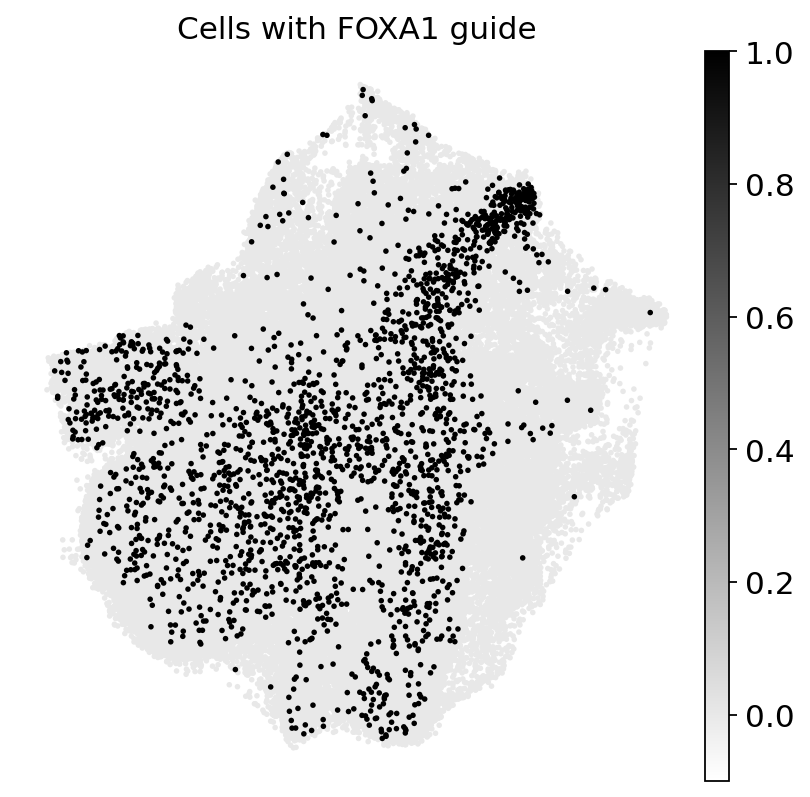

In [7]:
# Cells with a FOXA1 guide
fig = sc.pl.embedding(
    adata,
    basis="umap",
    color="guide_FOXA1",
    cmap="binary",
    vmin=-0.1,  # to ensure 0 does not correspond to white
    size=25,
    title="Cells with FOXA1 guide",
    return_fig=True,
)
fig.set_size_inches(6, 6)

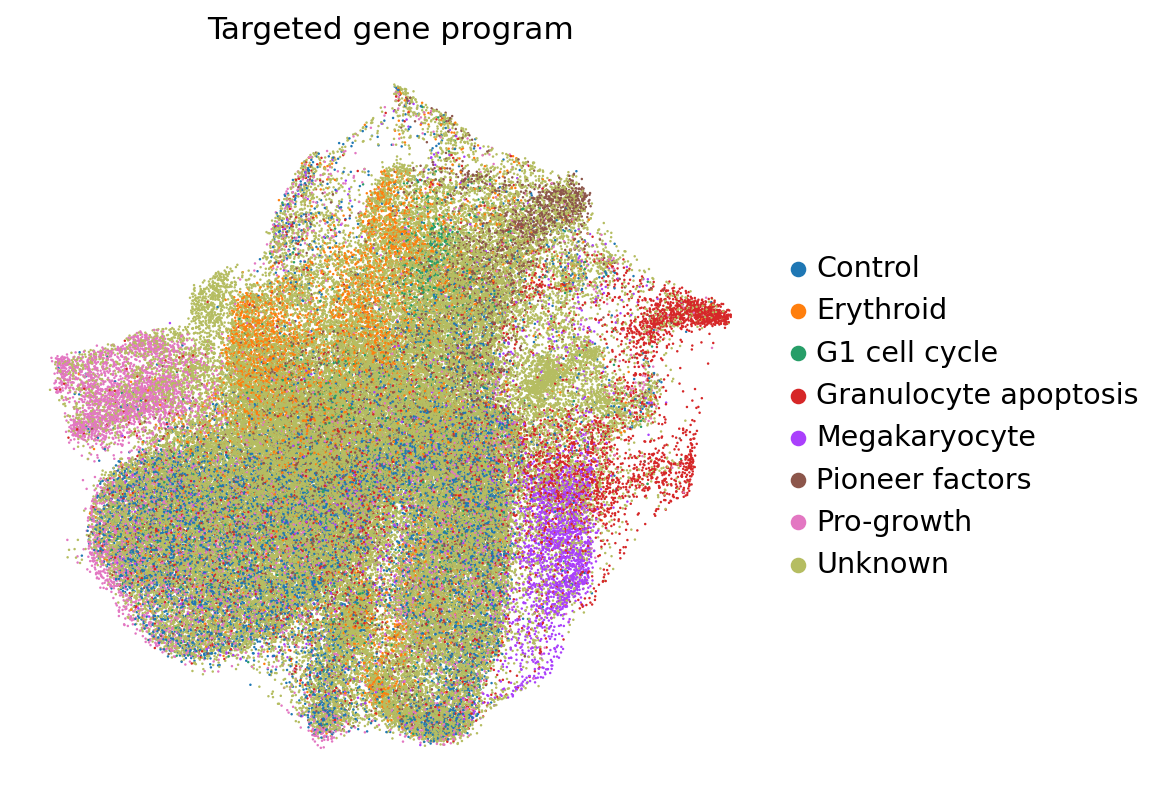

In [8]:
# Cells colored by the gene program targeted by their corresponding guide
fig = sc.pl.embedding(adata, basis="umap", color="gene_program", title="Targeted gene program", size=5, return_fig=True)
fig.set_size_inches(6, 6)

## 3. Data preprocessing

Perturb-seq experiments are a special scRNA-seq experiment to understanding the impact of perturbations. As such, data preprocessing is similar to our previous scRNA-seq data analysis - library size is a technical artifact across cells which must be accounted for, for example - but also entails additional steps to boost the signal in our data. Remember: we are trying to assess potentially minute impacts on gene expression data which is already rife with noise and heavily under-sampled. Specifically, we are interested in cell states upon perturbation and will, thus, place each in the context of our control cells.

### Data normalization

#### Library size normalization

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.1</b>
  </div>
  <ol type="a">
    <li>Normalize the library size of each cell to 10,000.</li>
    <li>Subset to genes with mean normalized GEX larger than 0.5.</li>
  </ol>
</div>

In [9]:
# Implement your solution here
sc.pp.normalize_total(adata, target_sum=1e4)

normalizing counts per cell
    finished (0:00:05)


In [10]:
gene_mask = adata.X.mean(axis=0) > 0.5
adata = adata[:, gene_mask.A1]
print(f"After filtering, there are {adata.n_vars} genes in the dataset.")

After filtering, there are 4582 genes in the dataset.


#### Z-scoring

To assess the impact of perturbations, we compare the GEX observed in perturbed cells to those observed in control cells, i.e., a baseline. Thus, we z-score each gene w.r.t. GEX in control cells to (1) study GEX in terms of deviations relative to control cells and (2) place all genes on a similar scale. Here, to account for batch effects, we z-score each 10X lane separately (column _"gemgroup"_ in `adata.obs`). These transformed values no longer represent GEX itself but rather induction (positive z-score) and repression (negative z-score) upon perturbation.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.2</b>
  </div>
  Define the layer <i>znormed_wrt_control</i> as the 10X-lane-specific z-normalized data, i.e., for each lane
  <ol type="a">
    <li>Subset the normalized data to the given lane.</li>
    <li>Compute the mean and standard deviation of control cells in this subset.</li>
    <li>Set the standard deviation to at least 1e-6, to prevent division by zero and ensure numerical stability.</li>
    <li>Z-score the subset.</li>
  </ol>
</div>

**Self-check:** The overall mean z-normalized expression is -0.005573.

In [11]:
# Implement your solution here
import numpy as np
import scipy.sparse as sp

gemgroups = adata.obs["gemgroup"].unique()
print(f"The unique GEM groups in the dataset are: {gemgroups}")

all_adata_lanes = []

for lane in gemgroups:
    adata_lane = adata[adata.obs["gemgroup"] == lane].copy()
    control_mask = adata_lane.obs["perturbation_name"] == "control"
    control_data = adata_lane[control_mask].X.toarray()
    mean_control = control_data.mean(axis=0)
    std_control = control_data.std(axis=0)
    std_control = np.maximum(std_control, 1e-6) # Avoid division by zero and ensure numerical stability
    X = adata_lane.X.toarray()
    adata_lane.X = (X - mean_control) / std_control # Z-score normalization by control expression in each lane
    adata_lane.X = sp.csr_matrix(adata_lane.X) # Convert back to sparse format
    all_adata_lanes.append(adata_lane)

adata_zscore = sc.concat(all_adata_lanes)
adata_zscore = adata_zscore[adata.obs_names]
adata.layers['znormed_wrt_control'] = adata_zscore.X
print(f"Overall mean z-normalized expression is: {adata.layers['znormed_wrt_control'].mean():.6f}")


The unique GEM groups in the dataset are: [1, 2, 3, 4, 5, 6, 7, 8]
Categories (8, int64): [1, 2, 3, 4, 5, 6, 7, 8]


/tmp/ipykernel_2503771/1094194655.py:24: ImplicitModificationWarning: Setting element `.layers['znormed_wrt_control']` of view, initializing view as actual.
  adata.layers['znormed_wrt_control'] = adata_zscore.X


Overall mean z-normalized expression is: -0.005573


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 3.1</b>
  </div>
  Which gene has the largest across-cell-average deviation? Report both the gene and the numerical value, rounded to four decimals.
</div>

In [12]:
# Implement your solution here
deviation_max = adata.layers['znormed_wrt_control'].mean(axis=0).max()
deviation_max_gene_pos = adata.layers['znormed_wrt_control'].mean(axis=0).argmax()
deviation_max_gene = adata.var_names[deviation_max_gene_pos]
print(f"The gene with the largest deviation from control is {deviation_max_gene} with a mean z-normalized expression of {deviation_max:.4f}.")

The gene with the largest deviation from control is ALAS2 with a mean z-normalized expression of 0.6439.


### Pseudobulking

We generally care about **average** perturbation effects. Thus, to boost our signal and mitigate the sparsity of single-cell data, we aggregate cells with the same perturbation. Specifically, since most analysis is in practice done at mean level, we just group cells with the same perturbation together, thereby defining a so-called *pseudobulk* representation of our data. Pseudobulking loses the per cell information, but retains the per gene resolution; i.e, we can save the corresponding data in the `adata.varm` slot.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.3</b>
  </div>
  <ol type="a">
    <li>Define a pandas DataFrame with the z-normalized data as values, the cell barcodes as index, and gene names as columns.</li>
    <li>Add the perturbation information as a column.</li>
    <li>Use pandas <code>groupby</code> function to compute the mean z-scores for each perturbation.</li>
    <li>Save the pseudobolk data as an entry <i>zscore_pseudobulk</i> in <code>adata.varm</code>.</li>
  </ol>
</div>

In [13]:
# Implement your solution here
pseudobulk = pd.DataFrame(data=adata.layers['znormed_wrt_control'].toarray(), index=adata.obs_names, columns=adata.var_names)
pseudobulk["perturbation_name"] = adata.obs["perturbation_name"].values
pseudobulk_grouped = pseudobulk.groupby("perturbation_name").mean()
adata.varm['zscore_pseudobulk'] = pseudobulk_grouped.T
print(f"The shape of the pseudobulk grouped data is: {adata.varm['zscore_pseudobulk'].shape}")


/tmp/ipykernel_2503771/806314010.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pseudobulk_grouped = pseudobulk.groupby("perturbation_name").mean()


The shape of the pseudobulk grouped data is: (4582, 237)


Given the pseudobulked z-scores, we can embed the perturbations in a UMAP embedding similar to canonical scRNA-seq data. However, now, each dot corresponds to a perturbation, not a cell.

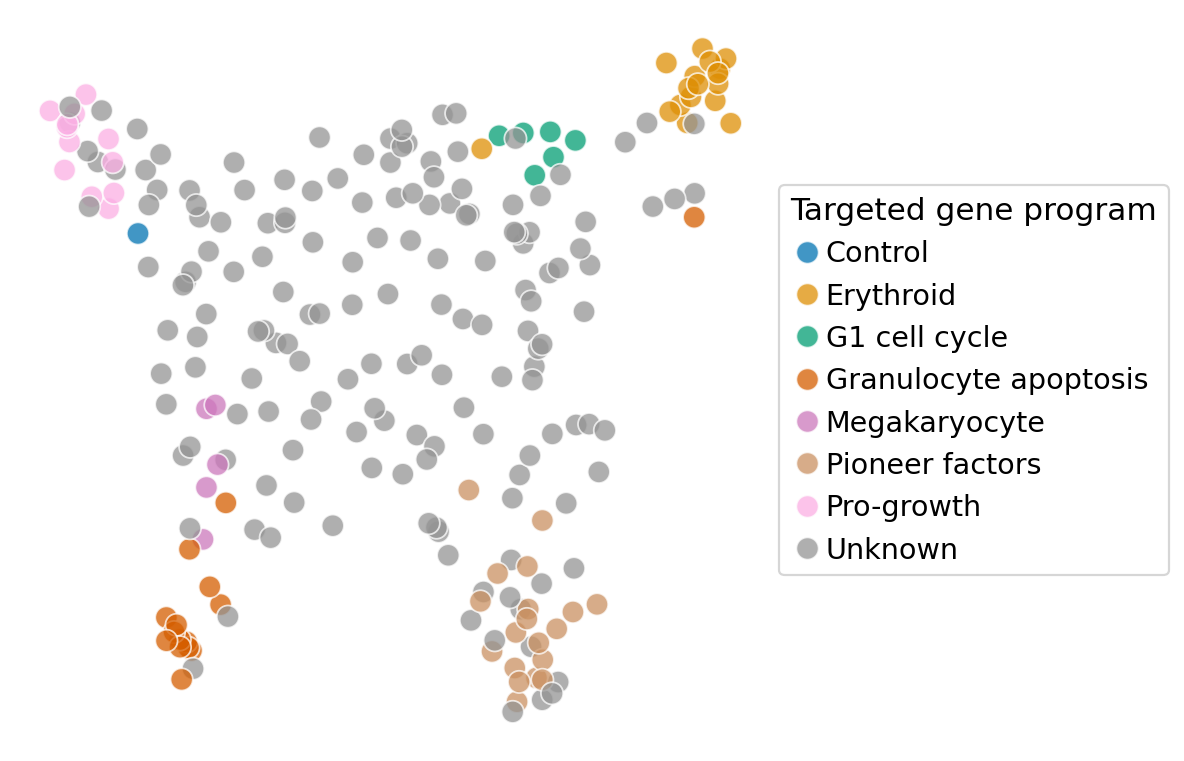

In [14]:
umap_model = UMAP(n_components=2)
data = umap_model.fit_transform(adata.varm["zscore_pseudobulk"].T) # Makes the pertubations the "samples" and the genes the "features"
data = pd.DataFrame(data, columns=["umap_1", "umap_2"], index=adata.varm["zscore_pseudobulk"].columns)
data = data.merge(
    adata.obs[["perturbation_name", "gene_program"]].drop_duplicates().set_index("perturbation_name"),
    left_index=True,
    right_index=True,
)

fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(data=data, x="umap_1", y="umap_2", hue="gene_program", palette="colorblind", s=100, alpha=0.75, ax=ax)
ax.axis("off")
ax.legend(title="Targeted gene program", loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.show()

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 3.2</b>
  </div>
  <ol type="a">
    <li>On average, which gene is most induced?</li>
    <li>On average, which gene is most repressed?</li>
    <li>On average, which gene is most impacted, i.e., induced or repressed?</li>
    <li>Which perturbation induces TAL1 the most?</li>
    <li>Which perturbation represses BRD4 the most?</li>
    <li>Which perturbation represses CEBPB the most?</li>
  </ol>
</div>

In [15]:
# Implement your solution here
gene_response_mean = adata.varm['zscore_pseudobulk'].mean(axis=1)
gene_most_induced = gene_response_mean.idxmax()
gene_most_repressed = gene_response_mean.idxmin()
gene_most_impacted = gene_response_mean.abs().idxmax()
print(f"The most induced gene across all perturbations is {gene_most_induced} with a mean z-normalized expression of {gene_response_mean[gene_most_induced]:.4f}.")
print(f"The most repressed gene across all perturbations is {gene_most_repressed} with a mean z-normalized expression of {gene_response_mean[gene_most_repressed]:.4f}.")
print(f"The most impacted gene across all perturbations is {gene_most_impacted} with a mean z-normalized expression of {gene_response_mean[gene_most_impacted]:.4f}.")

The most induced gene across all perturbations is ALAS2 with a mean z-normalized expression of 0.8777.
The most repressed gene across all perturbations is RANBP1 with a mean z-normalized expression of -0.6120.
The most impacted gene across all perturbations is ALAS2 with a mean z-normalized expression of 0.8777.


In [16]:
perturb_induce_tal1 = adata.varm['zscore_pseudobulk'].loc['TAL1'].idxmax()
perturb_repress_brd4 = adata.varm['zscore_pseudobulk'].loc['BRD4'].idxmin()
perturb_repress_cebpb = adata.varm['zscore_pseudobulk'].loc['CEBPB'].idxmin()
print(f"The perturbation that induces TAL1 the most is {perturb_induce_tal1}.")
print(f"The perturbation that represses BRD4 the most is {perturb_repress_brd4}.")
print(f"The perturbation that represses CEBPB the most is {perturb_repress_cebpb}.")

The perturbation that induces TAL1 the most is FEV+ISL2.
The perturbation that represses BRD4 the most is SAMD1+TGFBR2.
The perturbation that represses CEBPB the most is CBFA2T3+PRDM1.


## 4. Modeling the impacts of genetic interactions

Having processed our data to express relative perturbation-induced changes, we can now focus on the actual biological question at hand: **how do pairs of genes interact functionally to manipulate a downstream target program**? Answering this quesion computationally amounts to comparing the effects of single-gene activation to joint (combined) activation of a gene pair.

The basic premise is as follows: we will fit a linear model that predicts the effects $\Delta$ of joint activation of a pair of genes (A+B) as a linear combination of individual genes in that pair (A and B separately), i.e.,

$$\Delta_{A+B} = \alpha \Delta_{A} + \beta \Delta_{B},$$

with regression parameters $\alpha$ and $\beta$.

Based on these fits, we then employ the following logic:

1. *Good prediction with (approximately) equal values for $\alpha$ and $\beta$* suggests perturbations impact gene expression additively in a synergystic effect.
2. *Good prediction with different values for $\alpha$ and $\beta$* suggests perturbations impact gene expression additively but the effect of the perturbed genes differs; e.g., if $\alpha$ is much larger than $\beta$, then gene A dominates in the sense that its impacts overwhelm the impacts of the other perturbation.
3. *Poor prediction* suggests that the genes combine in a non-linear fashion such as when over-expressing both genes is necessary to induce the effect, and each individual gene perturbation alone does not mimic the combined effect in any sense.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.1</b>
  </div>
  Plot the pseudobulked z-scores of the <i>CBL+CNN1</i> perturbation against the ones of each individual perturbation, respectively. Based on this plot, Which of our three scenarios do you expect to hold?
</div>

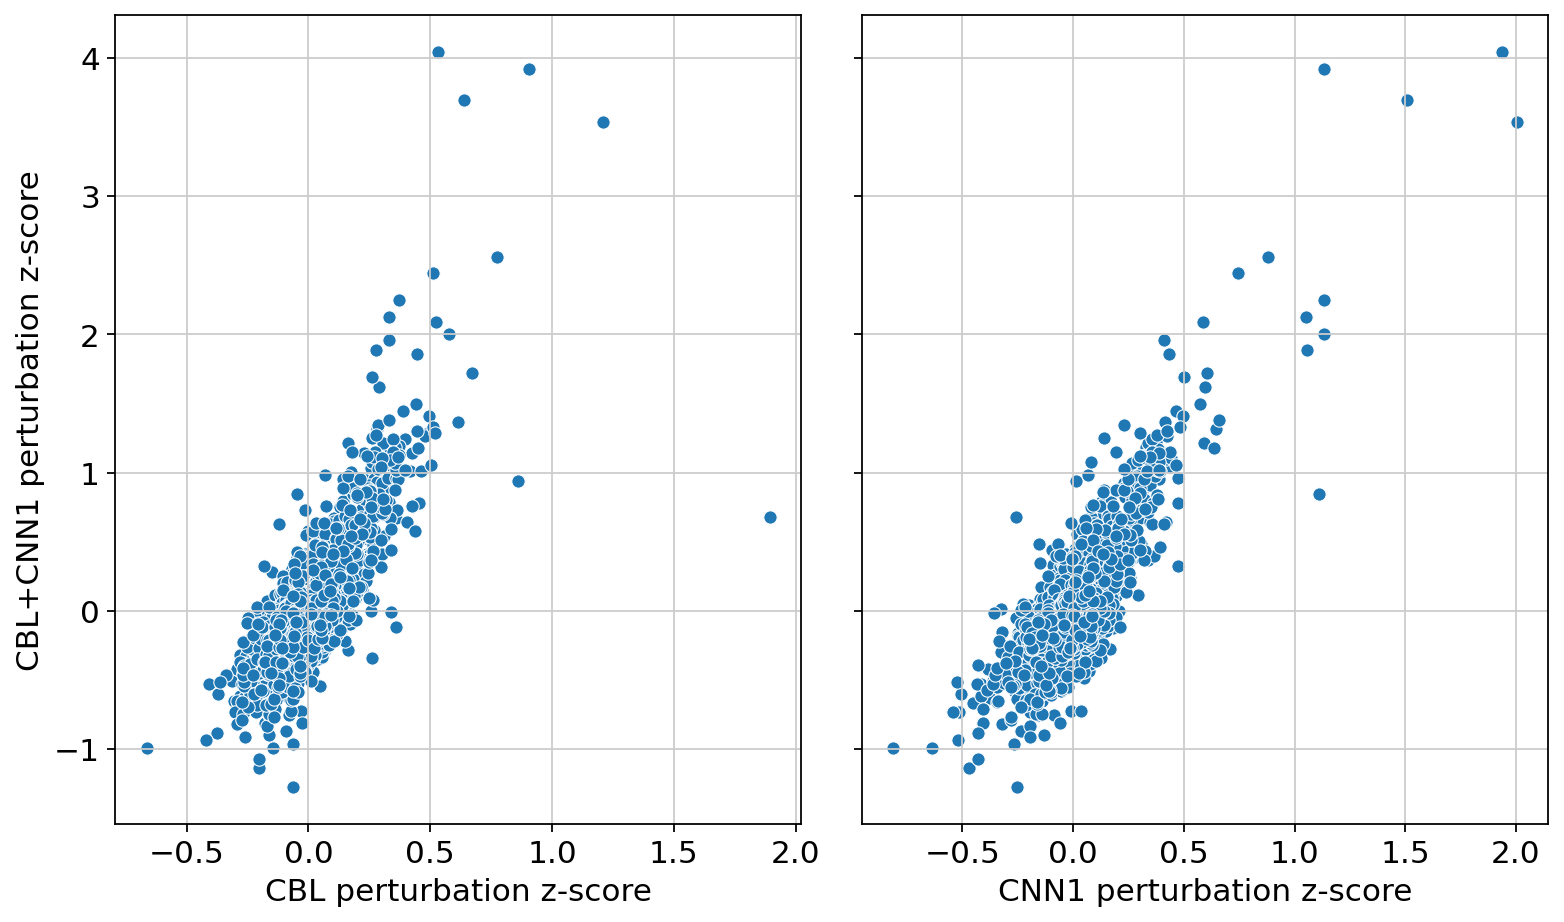

In [17]:
# Implement your solution here
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

sns.scatterplot(x=adata.varm["zscore_pseudobulk"]["CBL"], y=adata.varm["zscore_pseudobulk"]["CBL+CNN1"], ax=axes[0])
axes[0].set_xlabel("CBL perturbation z-score")
axes[0].set_ylabel("CBL+CNN1 perturbation z-score")

sns.scatterplot(x=adata.varm["zscore_pseudobulk"]["CNN1"], y=adata.varm["zscore_pseudobulk"]["CBL+CNN1"], ax=axes[1])
axes[1].set_xlabel("CNN1 perturbation z-score")
axes[1].set_ylabel("CBL+CNN1 perturbation z-score")

plt.tight_layout()
plt.show()

It looks like its scenario 1 where this a good prediction with equal values for pertubation impact of each individual gene suggesting a synergistic effect. 

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.2</b>
  </div>
  Define a function <code>linear_interaction_model</code> that takes the pseudobulked data and a double perturbation as input (keywords <code>pseudobulk</code> and <code>perturbation</code>) as well as an optional argument to return the model prediction (keyword <code>return_pred</code> with default set to <code>False</code>), fits the above defined linear model, and returns the fitted coefficients, their signed log-fold change, and the models coefficient of determination (R2; R-squared) value. Proceed as follows:
  <ol type="a">
    <li>Extract the individual gene names from the <code>perturbation</code> variable.</li>
    <li>Define the data matrix for the linear model; i.e., extract the pseudobulk data corresponding to the individual genes of the double perturbation.</li>
    <li>Define the response variable for the linear model; i.e., extract the pseudobulk data corresponding to the double perturbation.</li>
    <li>Use <a href="https://scikit-learn.org/stable/">scikit-learn's</a> LinearRegression class to fit the linear model.</li>
    <li>Extract the fitted coefficients and the R2 value.</li>
    <li>Compute the signed log-foldchange of the coefficients, i.e., the log-foldchange of their absolute values multiplied by the product of their signs.</li>
    <li>Return a pandas DataFrame indexed by the double perturbation with columns <i>coef_1</i>, <i>coef_2</i>, <i>lfc</i>, <i>r2</i>.</li>
  </ol>
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 4.1</b>
  </div>
  Why do we compute a signed LFC?
  <blockquote>The signs of the regression parameters may differ and, thus, lead to negative ratios for which the log is not defined.</blockquote>
</div>

**Self-check:** For the *CBL+CNN1* perturbation, the fitted coefficients are 1.1156 and 1.2811, with an R-squared value of 0.7395.

In [18]:
# Implement your solution here
def linear_interaction_model(
    pseudobulk: pd.DataFrame, perturbation: str, return_pred: bool = False
) -> pd.DataFrame | tuple[pd.DataFrame, pd.Series]:
    """Fit and evaluate linear model.

    Parameters
    ----------
    pseudobulk
        Pseudobulked z-scored, indexed by gene name and with perturbations as column names.
    perturbation
        The name of the double perturbation.
    return_pred
        Return the model prediction.

    Returns
    -------
    If `return_pred==False`, a pandas DataFrame with columns
    * `coef_1`: coefficient for first gene in double perturbation
    * `coef_2`: coefficient for second gene in double perturbation
    * `lfc`: signed log-foldchange of coefficients
    * `r2`: r-squared of model fit
    otherwise the DataFrame and the model prediction as a pandas Series, index by gene names.
    """

    # Recover the individual genes of the perturbation
    perturb_genes = perturbation.split('+')

    # Define the data matrix and response variable
    data_gene_A = pseudobulk[perturb_genes[0]]
    data_gene_B = pseudobulk[perturb_genes[1]]
    data_response = pseudobulk[perturbation]

    # Define and fit the linear regression
    from sklearn.linear_model import LinearRegression
    model = LinearRegression()
    X = pd.DataFrame({
        'gene_A': data_gene_A,
        'gene_B': data_gene_B
    })
    model.fit(X, data_response)

    # Extract the data of the fit
    coef_1 = model.coef_[0]
    coef_2 = model.coef_[1]
    r2 = model.score(X, data_response)
    signed_lfc = np.log2(np.abs(coef_1) / np.abs(coef_2)) * np.sign(coef_1) * np.sign(coef_2) # Signed LFC of the coefficients avoids computing log2 on negative values and gives an interpretable directionality to the fold change

    # Compute prediction
    pred = model.predict(X)

    # Format results
    if return_pred:
        return pd.DataFrame({
            'coef_1': [coef_1],
            'coef_2': [coef_2],
            'lfc': [signed_lfc],
            'r2': [r2]
        }, index=[perturbation]), pd.Series(pred, index=pseudobulk.index)
    else:
        return pd.DataFrame({
            'coef_1': [coef_1],
            'coef_2': [coef_2],
            'lfc': [signed_lfc],
            'r2': [r2]
        }, index=[perturbation])

In [19]:
results, pred = linear_interaction_model(adata.varm['zscore_pseudobulk'], perturbation="CBL+CNN1", return_pred=True)

We want a possibility to visually assess how individual single perturbation compare to their corresponding double perturbation and the fitted model.
<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.3</b>
  </div>
  Define a function <code>plot_linear_interaction_model</code> that takes the pseudobulked data, the result and prediction of the linear model fit and the number of genes to visualize as input (keywords <code>pseudobulk</code>, <code>lm_res</code>, <code>lm_pred</code>, and <code>n_genes</code>) and visualizes the pseudobulked deviations from baseline for the double perturbation, its individual genes, and the predicted deviation for a double perturbation based on the linear model. Proceed as follows:
  <ol type="a">
    <li>Extract the pseudobulked z-scores for the double perturbation and individual genes to define a DataFrame indexed by the first and second gene, the double perturbation itself, and the prediction of the linear model.</li>
    <li>Subset this DataFrame to the <code>n_genes</code> most variable genes across the three perturbations.</li>
    <li>Visualize the data frame with seaborn's <code>clustermap</code> function (keywords <code>cmap="coolwarm"</code>, <code>center=0</code>, <code>row_cluster=False</code>, <code>robust=True</code>).</li>
  </ol>
</div>

In [46]:
# Implement your solution here
def plot_linear_interaction_model(
    pseudobulk: pd.DataFrame, lm_res: pd.DataFrame, lm_pred: pd.Series, n_genes: int
) -> None:
    """Plot the clustermap of the z-scored pseudobulks for a double perturbation, its definint genes, and the linear model fit.

    Parameters
    ----------
    pseudobulk
        Pseudobulked z-scored, indexed by gene name and with perturbations as column names.
    lm_res
        Result of linear model fit.
    lm_pred
        Prediction of linear model fit.
    n_genes
        Number of highly variable genes to show.

    Returns
    -------
    Nothing, only plots the data.
    """
    # Extract the double pertrubation and its genes
    perturbation = lm_res.index[0]
    perturb_genes = perturbation.split('+')

    # Define data frame of pseudobulk z-scores
    pseudobulk_subset = pseudobulk[[perturb_genes[0], perturb_genes[1], perturbation]].copy()
    data = pseudobulk_subset.copy()
    data['lm_pred'] = lm_pred

    # Subset to n_genes highly variable genes -> In this case just means based on variance
    data = data.loc[pseudobulk_subset.var(axis=1).nlargest(n_genes).index] # Variance by gene across the three perturbations

    # Plot data
    g = sns.clustermap(
        data=data.T,
        cmap='coolwarm',
        center=0,
        row_cluster=False,
        robust=True,
        figsize=(16,10)
        )
    g.fig.suptitle("Linear interaction model fit for perturbation: " + perturbation)
    plt.show()


### Synergystic effect

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.4</b>
  </div>
  Use the previously defined functions to assess the <i>CBL+CNN1</i> perturbation (use <code>n_gene=100</code>) - an example of a synergystic effect.
</div>

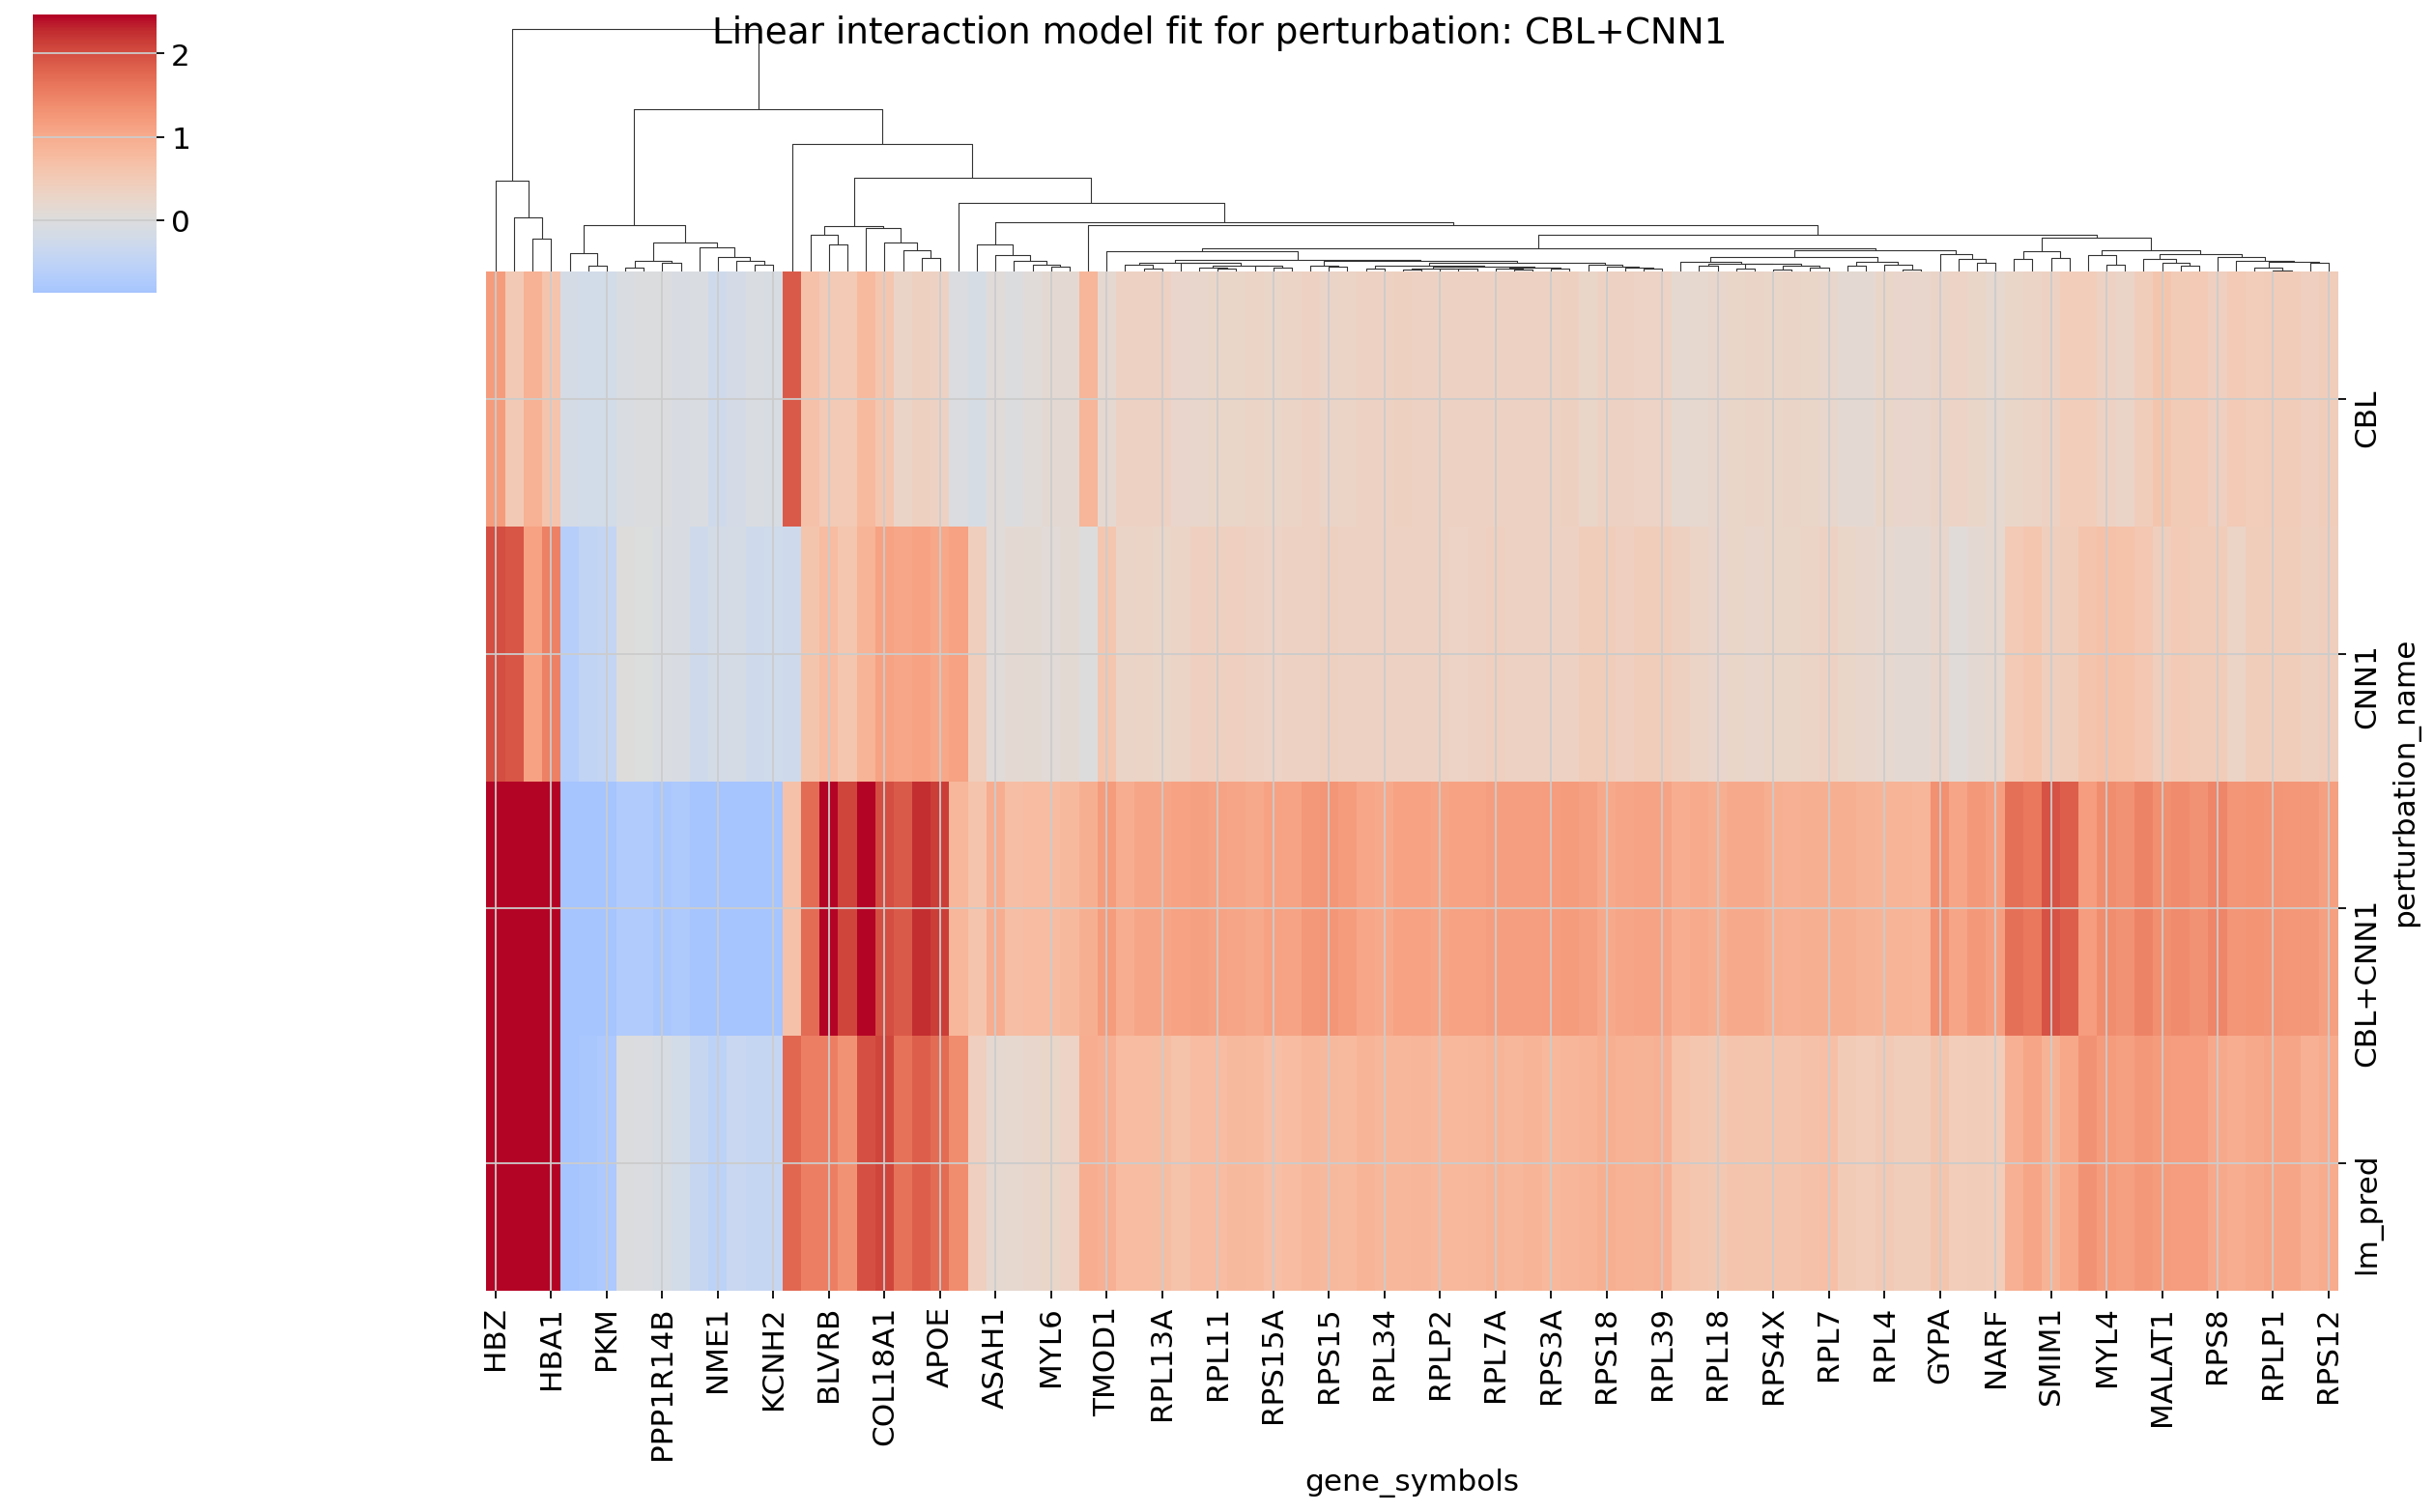

In [47]:
# Implement your solution here
plot_linear_interaction_model(adata.varm['zscore_pseudobulk'], results, pred, n_genes=100)

### Double pertrubation with a dominant gene

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.5</b>
  </div>
  Use the previously defined functions to assess the <i>CEBPA+KLF1</i> perturbation (use <code>n_gene=100</code>) - an example for an effect with a dominant gene.
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 4.2</b>
  </div>
  Which gene is the dominant one in the <i>CEBPA+KLF1</i> perturbation?
</div>

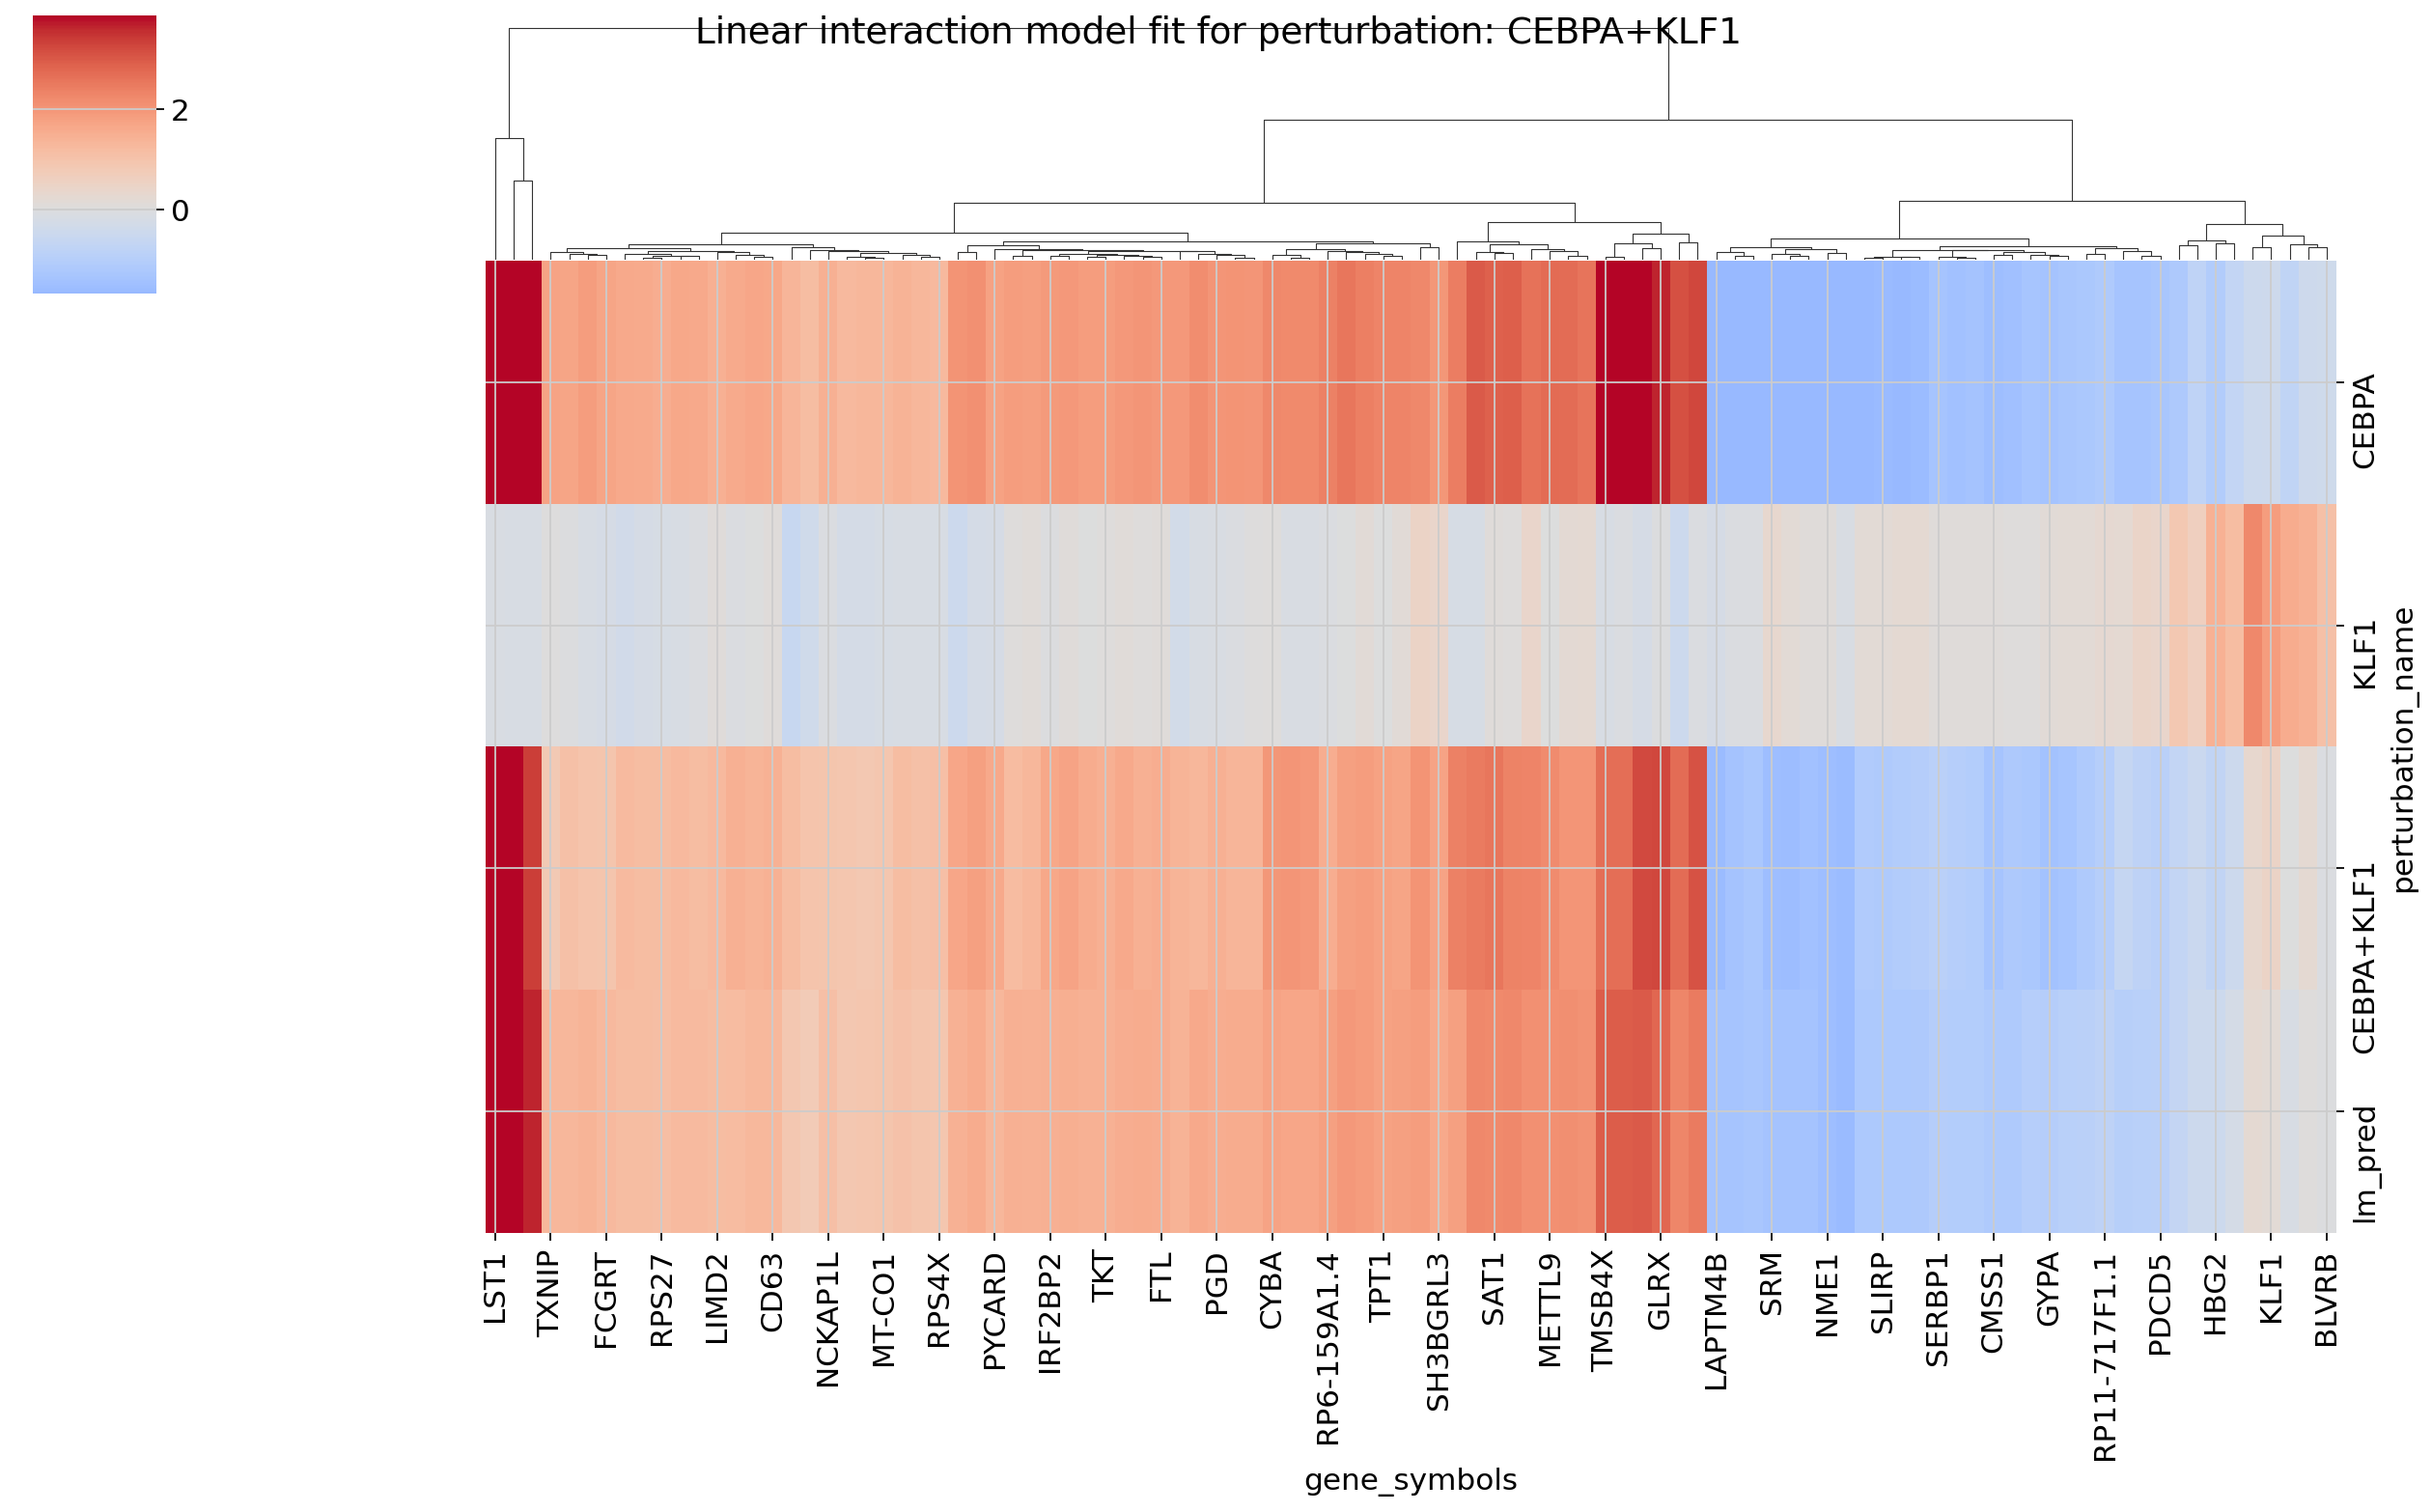

In [48]:
# Implement your solution here
results_2, pred_2 = linear_interaction_model(adata.varm['zscore_pseudobulk'], perturbation="CEBPA+KLF1", return_pred=True)
plot_linear_interaction_model(adata.varm['zscore_pseudobulk'], results_2, pred_2, n_genes=100)

### Non-linear effect

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.5</b>
  </div>
  Use the previously defined functions to assess the <i>PLK4+STIL</i> perturbation (use <code>n_gene=100</code>) - an example for a non-linear effect.
</div>

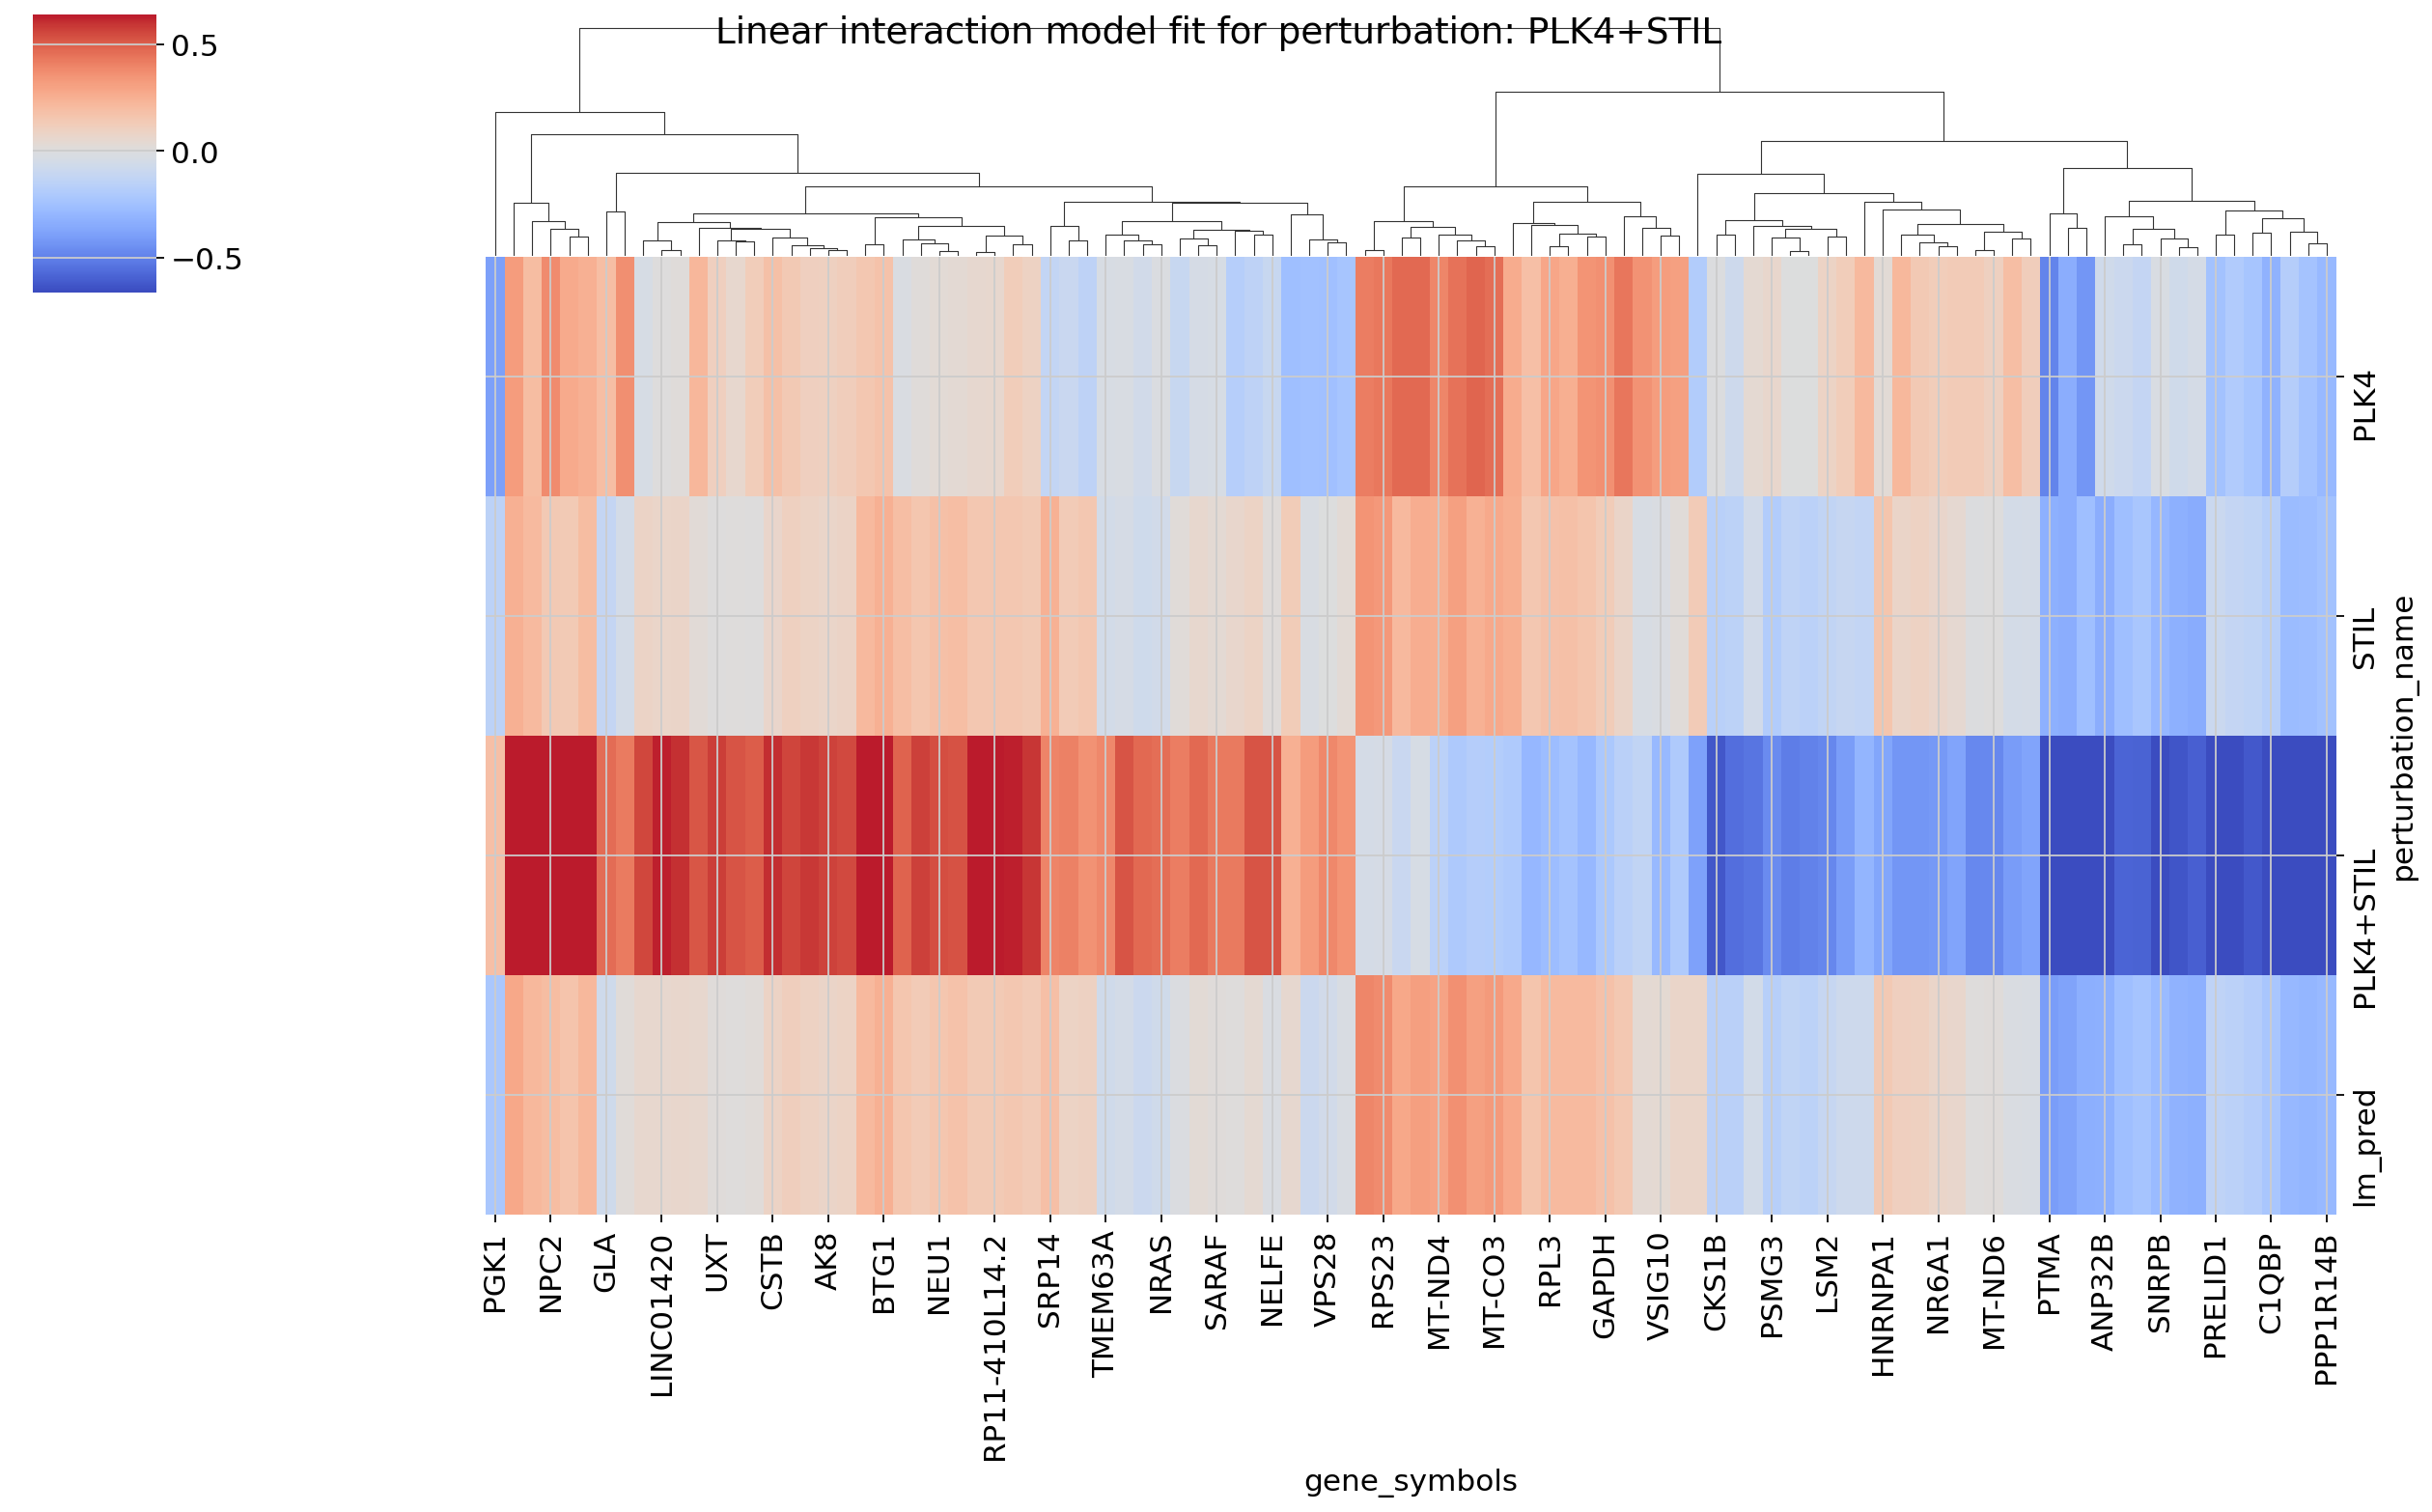

In [49]:
# Implement your solution here
results_3, pred_3 = linear_interaction_model(adata.varm['zscore_pseudobulk'], perturbation="PLK4+STIL", return_pred=True)
plot_linear_interaction_model(adata.varm['zscore_pseudobulk'], results_3, pred_3, n_genes=100)

### Systematic assessment of all double perturbations

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.5</b>
  </div>
  Use the <code>linear_interaction_model</code> function to collect the linear model results for all double perturbations in a single pandas DataFrame, indexed by the double perturbation (variable name <code>lm_res</code>).
</div>

In [58]:
# Implement your solution here
double_perturbation_mask = perturbations.apply(lambda x: len(x) == 2)
double_perturbations = perturbations[double_perturbation_mask].apply(lambda x: '+'.join(x)).unique()

lm_res_list = []
for perturbation in double_perturbations:
    lm_res_per_pertubation = linear_interaction_model(adata.varm['zscore_pseudobulk'], perturbation=perturbation, return_pred=False)
    lm_res_list.append(lm_res_per_pertubation)
lm_res = pd.concat(lm_res_list)

/athena/cayuga_0083/scratch/pfw4001/envs/qibs2026-py312/lib/python3.12/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


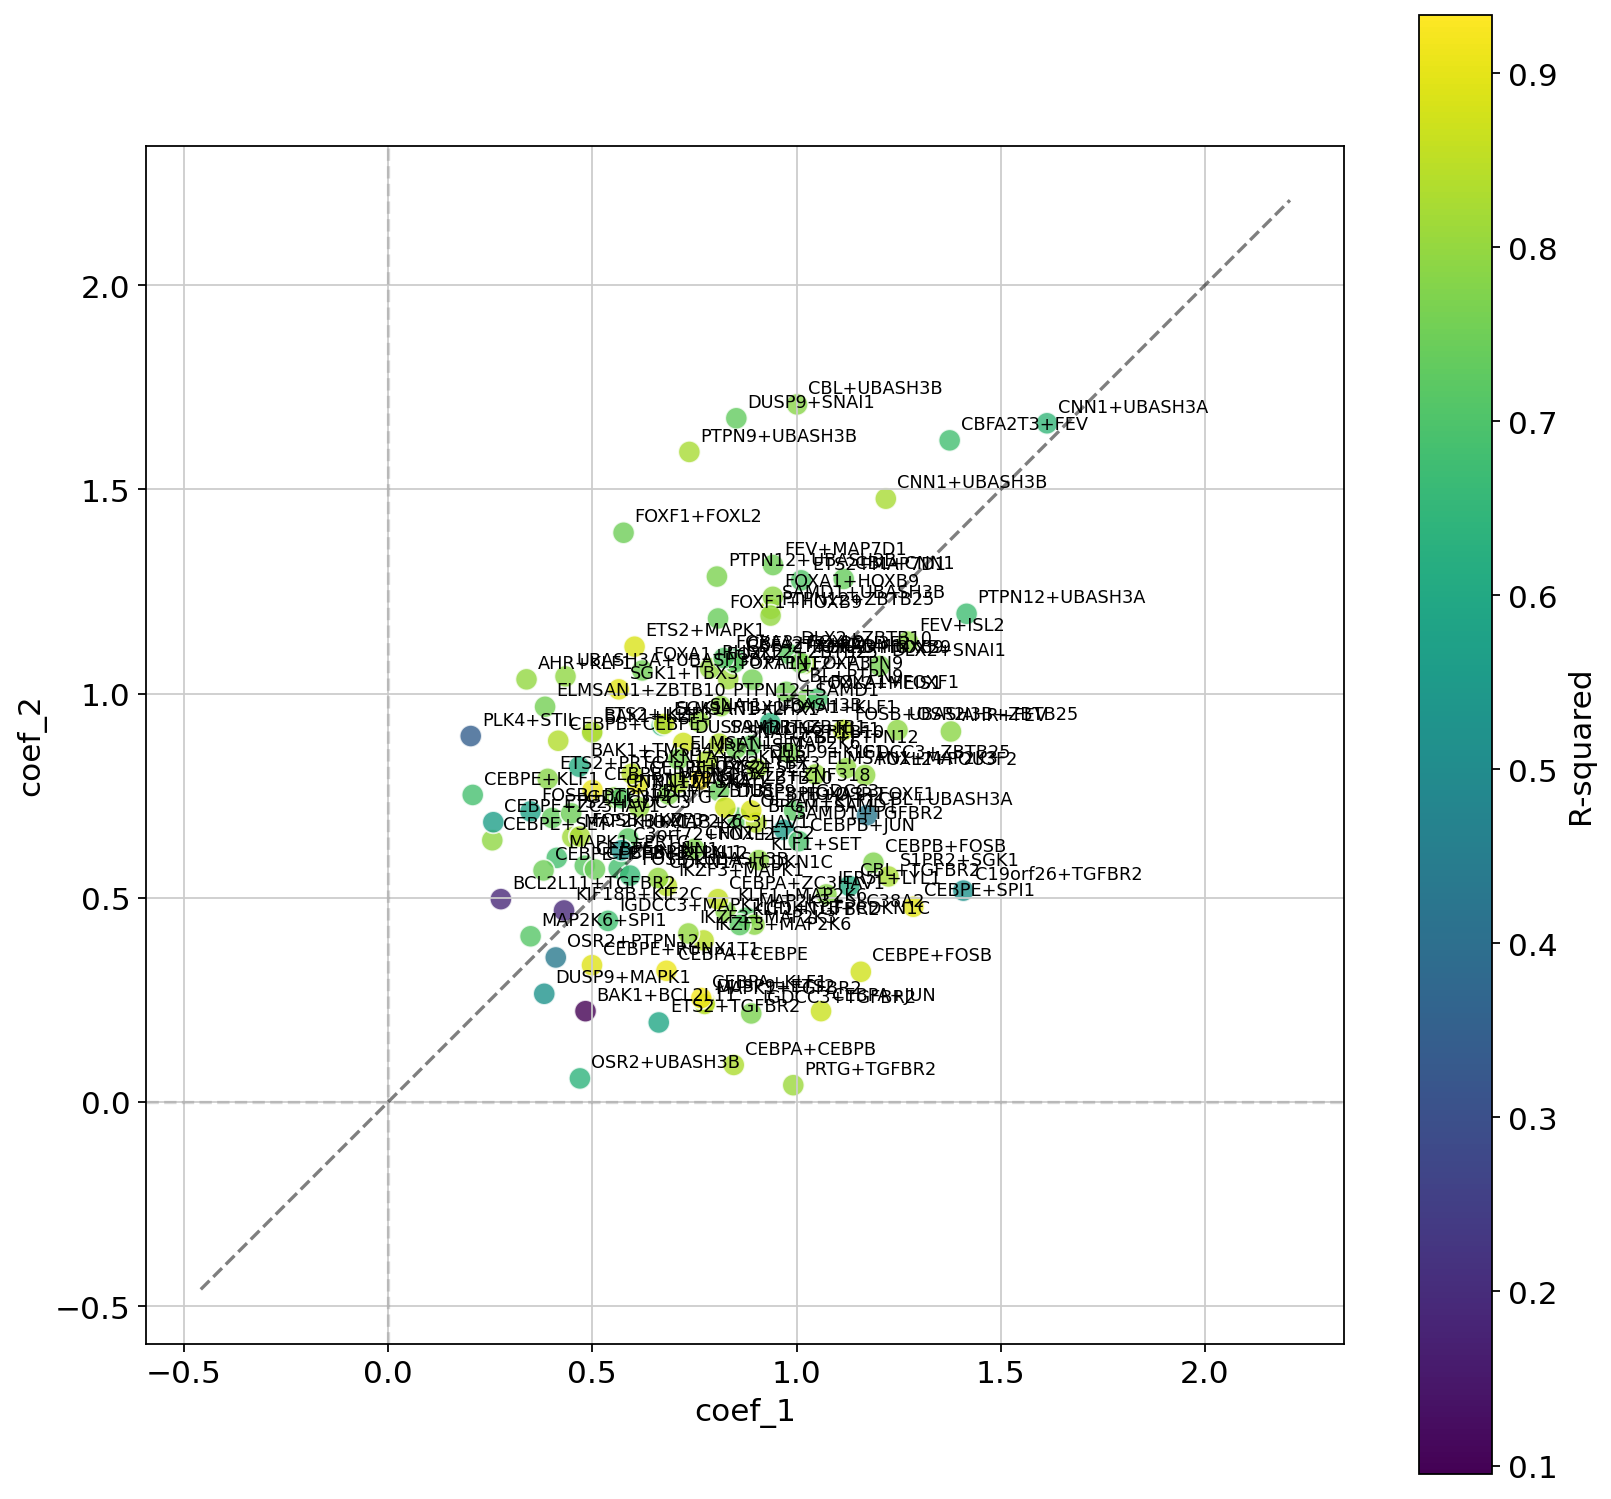

In [59]:
fig, ax = plt.subplots(figsize=(12, 12))

cmap = sns.color_palette("viridis", as_cmap=True)
vmin, vmax = lm_res["r2"].min(), lm_res["r2"].max()
norm = Normalize(vmin=vmin, vmax=vmax)

sns.scatterplot(
    data=lm_res, x="coef_1", y="coef_2", hue="r2", palette=cmap, norm=norm, legend=False, s=100, alpha=0.8, ax=ax
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig.colorbar(sm, ax=ax, label="R-squared")

max_val = lm_res[["coef_1", "coef_2"]].max().max() + 0.5
min_val = lm_res[["coef_1", "coef_2"]].min().min() - 0.5
ax.plot([min_val, max_val], [min_val, max_val], "k--", alpha=0.5, label="coef1 = coef2")

ax.axhline(y=0, color="gray", linestyle="--", alpha=0.3)
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)

for _, row in lm_res.iterrows():
    ax.annotate(row.name, (row["coef_1"], row["coef_2"]), xytext=(5, 5), textcoords="offset points", fontsize=8)

ax.set(aspect="equal")
plt.show()

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 4.2</b>
  </div>
  <ol type="a">
    <li>Which double perturbation is best explained by the linear model?</li>
    <li>Which double perturbation appears to be most non-linear?</li>
    <li>Which double perturbation is the most synergystic, amongst those with R-squared > 0.6?</li>
    <li>Which gene is the most dominant, amongst double perturbations with R-squared > 0.6?</li>
  </ol>
</div>

In [66]:
# Implement your solution here
best_explained = lm_res['r2'].idxmax()
print(f"The double perturbation with the best explained variance by the linear model is {best_explained} with an R-squared of {lm_res.loc[best_explained, 'r2']:.4f}.")

worst_explained = lm_res['r2'].idxmin() # i.e. most non-linear
print(f"The double perturbation with the worst explained variance by the linear model is {worst_explained} with an R-squared of {lm_res.loc[worst_explained, 'r2']:.4f}.")

lm_res['coef_diff'] = np.abs(lm_res['coef_1'] - lm_res['coef_2'])
most_synergistic = lm_res['coef_diff'][lm_res['r2'] > 0.6].idxmin() # Most synergistic among those with at least some linear explainability
print(f"The most synergistic double perturbation among those with R-squared > 0.6 is {most_synergistic} with a coefficient difference of {lm_res.loc[most_synergistic, 'coef_diff']:.4f}.")

lm_res['gene_A'] = lm_res.index.str.split('+').str[0]
lm_res['gene_B'] = lm_res.index.str.split('+').str[1]
most_dominant_pair = lm_res['coef_diff'][lm_res['r2'] > 0.6].idxmax() # Most dominant pair among those with at least some linear explainability
most_dominant_gene = lm_res.loc[most_dominant_pair, 'gene_A' if abs(lm_res.loc[most_dominant_pair, 'coef_1']) > abs(lm_res.loc[most_dominant_pair, 'coef_2']) else 'gene_B']
print(f"The most dominant double perturbation among those with R-squared > 0.6 is {most_dominant_pair} with the most dominant gene being {most_dominant_gene} with a coefficient of {lm_res.loc[most_dominant_pair, 'coef_1' if most_dominant_gene == lm_res.loc[most_dominant_pair, 'gene_A'] else 'coef_2']:.4f} and the other gene having a coefficient of {lm_res.loc[most_dominant_pair, 'coef_2' if most_dominant_gene == lm_res.loc[most_dominant_pair, 'gene_A'] else 'coef_1']:.4f}.")

The double perturbation with the best explained variance by the linear model is TBX2+TBX3 with an R-squared of 0.9334.
The double perturbation with the worst explained variance by the linear model is BAK1+BCL2L11 with an R-squared of 0.0949.
The most synergistic double perturbation among those with R-squared > 0.6 is CEBPB+LYL1 with a coefficient difference of 0.0072.
The most dominant double perturbation among those with R-squared > 0.6 is PRTG+TGFBR2 with the most dominant gene being PRTG with a coefficient of 0.9921 and the other gene having a coefficient of 0.0413.
